<a href="https://colab.research.google.com/github/karthik-garlapally/Machine_Lerning/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Importing csv file ###
downloaded a iris.csv from online, which is a public data set

In [ ]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving iris.csv to iris.csv
User uploaded file "iris.csv" with length 5107 bytes


now reading the csv file that was imported

In [ ]:
import pandas as pd
iris_data = pd.read_csv('iris.csv')
df = iris_data.rename(columns={
    'SepalLengthCm': 'sepal_length',
    'SepalWidthCm': 'sepal_width',
    'PetalLengthCm': 'petal_length',
    'PetalWidthCm': 'petal_width'
})
df = df.drop(columns=['Id', 'Species'])
display(df.head())

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
import numpy as np

df.iloc[3, 0] = np.nan
df.iloc[20, 2] = np.nan
df.iloc[50, 1] = np.nan

Make an entire row missing

In [ ]:

df.iloc[3] = np.nan
df.isnull()

,sepal_length,sepal_width,petal_length,petal_width
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,True,True,True,True
4,False,False,False,False
...,...,...,...,...
145,False,False,False,False
146,False,False,False,False
147,False,False,False,False
148,False,False,False,False


 Make an entire column partially missing


In [ ]:
df.loc[0:5, 'sepal_length'] = np.nan
df.isnull()

,sepal_length,sepal_width,petal_length,petal_width
0,True,False,False,False
1,True,False,False,False
2,True,False,False,False
3,True,True,True,True
4,True,False,False,False
...,...,...,...,...
145,False,False,False,False
146,False,False,False,False
147,False,False,False,False
148,False,False,False,False


In [ ]:
import pandas as pd
iris_data =  pd.read_csv('iris.csv')

df = iris_data.rename(columns={
    'SepalLengthCm': 'sepal_length',
    'SepalWidthCm': 'sepal_width',
    'PetalLengthCm': 'petal_length',
    'PetalWidthCm': 'petal_width'
})

df = df.drop(columns=['Id', 'Species'])

df

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
import random

for i in range(10):
    row = random.randint(0, len(df)-1)
    col = random.randint(0, len(df.columns)-1)
    df.iloc[row, col] = np.nan

###Imputation Method

Forward Fill

In [ ]:
df_ffill = df.copy()

df_ffill = df_ffill.ffill()

print("Missing values after Forward Fill:")
print(df_ffill.isnull().sum())

Missing values after Forward Fill:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64


Backword Fill

In [ ]:
df_bfill = df.copy()

df_bfill = df_bfill.bfill()

print("Missing values after Backward Fill:")
print(df_bfill.isnull().sum())

Missing values after Backward Fill:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64


In [ ]:
# Mean Imputation
df_mean = df.copy()

df_mean = df_mean.fillna(df_mean.mean())

print("Missing values after Mean Imputation:")
print(df_mean.isnull().sum())

Missing values after Mean Imputation:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64


# Correlation Matrix

In [ ]:
corr_matrix = df.corr()

print("\nCorrelation Matrix:")
print(corr_matrix)



Correlation Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.125050      0.873318     0.814053
sepal_width      -0.125050     1.000000     -0.410378    -0.367461
petal_length      0.873318    -0.410378      1.000000     0.963337
petal_width       0.814053    -0.367461      0.963337     1.000000


 Find highly correlated feature pairs

In [ ]:

threshold = 0.8

print("\nHighly Correlated Features (|correlation| > 0.8):")

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            print(f"{corr_matrix.columns[i]} <--> "
                  f"{corr_matrix.columns[j]} : "
                  f"{corr_matrix.iloc[i, j]:.2f}")



Highly Correlated Features (|correlation| > 0.8):
petal_length <--> sepal_length : 0.87
petal_width <--> sepal_length : 0.81
petal_width <--> petal_length : 0.96


Heatmap Visualization

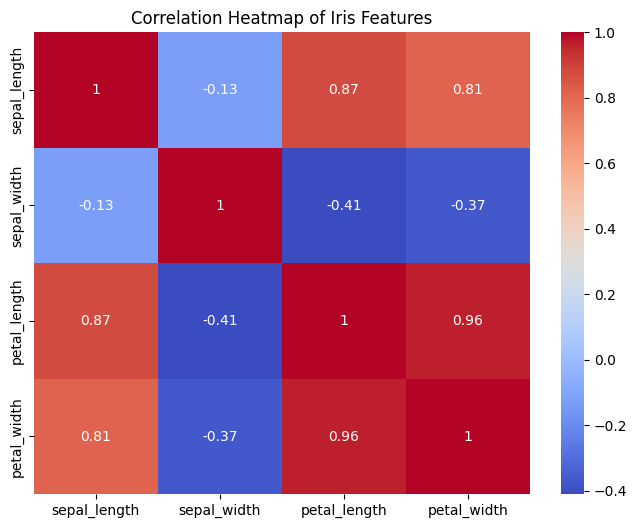

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',

)

plt.title('Correlation Heatmap of Iris Features')
plt.show()

#1. Data Frame

A Data Frame is a two-dimensional tabular data structure in the Pandas library that stores data in rows and columns, similar to an Excel spreadsheet or a database table.

#2. iloc

iloc (Integer Location) is a Pandas indexing method used to select rows and columns from a DataFrame based on their integer (position-based) indices.

#3. Imputation and Its Methods

Imputation is the process of replacing missing values in a dataset with suitable values to make the data complete for analysis.

Methods of Imputation:

Mean Imputation: Replaces missing values with the average of the column.

Median Imputation: Replaces missing values with the middle value of the column.

Mode Imputation: Replaces missing values with the most frequently occurring value.

Forward Fill (ffill): Replaces missing values with the previous valid value.

Backward Fill (bfill): Replaces missing values with the next valid value.

Constant Value Imputation: Replaces missing values with a fixed value such as 0 or "Unknown".
#4. Correlation

Correlation is a statistical measure that indicates the strength and direction of the relationship between two variables. Its value ranges from -1 to +1.

#5. Heatmap

A Heatmap is a graphical representation of data that uses colors to show the magnitude of values. It is commonly used to visualize a correlation matrix, making it easier to identify relationships between variables.